In [1]:
import importlib
import utils.functions as functions 
import utils.pre_processing as pre_processing
importlib.reload(pre_processing)
from utils.pre_processing import *
importlib.reload(functions)
from utils.functions import *

#org
import shutil 
import torch
import numpy as np
import warnings
import os, re, glob
from scipy import interpolate
import pandas as pd

#images
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tifffile as tiff
from matplotlib.animation import FuncAnimation, PillowWriter

#scientific libraries
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, LaplaceBootstrapTest



from pathlib import Path
root_dir = Path(".")
print(root_dir)

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.


/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/preproc/subsampling.py:26: ImportWarning: bottleneck package not found. Fall back to numpy
  warnings.warn(msg, ImportWarning)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/psfsub/svd.py:16: ImportWarning: Cupy not found. Do you have a GPU? Consider setting up a CUDA environment and installing cupy >= 2.0.0
  warnings.warn(msg, ImportWarning)
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/vip_hci/psfsub/medsub.py:43: ImportWarning: bottleneck package not found. Fall back to numpy
  warnings.warn(msg, ImportWarning)


# Test display settings effect

I took 7 images where I changed the display mode (normal, logscale), and the contrast, and I want to check if it had any effect on the frames taken.

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/test_display/'
#ros = [0.50, 0.70, 1.00]
test = np.concatenate([
    tiff.imread(
        sorted(glob.glob(f"{folder}*.tif"))
    )
    #for windspeed in ros
])
test  = test.astype(np.float32) #/ 65535

In [ ]:
test_croped = crop_stack(test)
print(test_croped.shape)

In [ ]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Counts')
plt.title('STD PSF')

In [ ]:
test_croped  = test_croped.astype(np.float32) / 65535

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Fraction of Saturation')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Fraction of Saturation')
plt.title('STD PSF')

plt.suptitle('Numerical error')

# Pre-Processing of one stack

- Create master dark frame: median of 3500 dark frames of 25ms, in counts
- Center
- Crop
- Subtract df
- divide by 65535


In [ ]:
radius = 55

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/darks_2026-07-22T10-28-49.8'
df = tiff.imread(glob.glob(f"{folder}*.tif"))
#df  = df.astype(np.float32) #/ 65535
df = crop_stack(df, radius = radius)
master_df = np.median(df, axis = 0)
print(master_df.shape)

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/psf'
sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
sci_img = crop_stack(sci_img,  radius = radius)
sci_img_processed = (sci_img - master_df) 
sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
#np.save(f'/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))

# folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_17/non_coro_int_0.70ro_12.50ws'
# sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
# sci_img = crop_stack(sci_img,  radius = radius)
# sci_img_processed = (sci_img - master_df) 
# sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
# #np.save(f'/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))


print(sci_img_processed.shape)

In [ ]:
# non_coro_int  = np.load('/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy')
# non_coro_int = np.load('/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy')
# print(non_coro_int.shape, non_coro_int.shape)

In [ ]:
plt.figure(figsize = (10,14))

plt.subplot(3,2,1)
plt.imshow(master_df)
plt.colorbar(label = 'Counts')
plt.title('Master median dark frame')

plt.subplot(3,2,2)
plt.imshow(np.std(df, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('STD dark frame')

plt.subplot(3,2,3)
plt.imshow(np.log10(np.mean(sci_img, axis = 0)))
plt.colorbar(label = 'Log Counts')
plt.title(f'Raw Mean Image')

plt.subplot(3,2,4)
plt.imshow(np.log10(np.mean(sci_img_processed, axis = 0)*65535))
plt.colorbar(label = f'Log Counts')
plt.title(f'Pre-Processed Mean Image')

cutoff = 20
plt.subplot(3,2,5)
plt.imshow((np.mean(sci_img, axis = 0))[:cutoff, :cutoff])
plt.colorbar(label = ' Counts')
plt.title(f'Raw Mean Image \nBackground [0:{cutoff}, 0:{cutoff}]')

plt.subplot(3,2,6)
plt.imshow((np.mean(sci_img_processed, axis = 0))[:cutoff, :cutoff]*65535)
plt.colorbar(label = f' Counts')
plt.title(f'Pre-Processed Mean Image \nBackground [0:{cutoff}, 0:{cutoff}]')

# Speckle Diversity

## Method Testing

In [ ]:


folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed = run_pre_processing_with_outliers(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None
                       )

In [ ]:
frames = sci_img_processed

n_frames = frames.shape[0]

# Flatten frames
X = frames.reshape(n_frames, -1).astype(float)

# Mean-center each pixel across the dataset
X -= X.mean(axis=0)



In [ ]:
# PCA (SVD solver)
n_components = 5
pca = PCA(n_components=n_components, svd_solver="full")
pca_coords = pca.fit_transform(X)

#took 2m16s

In [ ]:
# PCA (SVD solver)
n_components = 3
pca2 = PCA(n_components=n_components, svd_solver="full")
pca_coords2 = pca2.fit_transform(X)

#took 2m

In [ ]:
# PCA (SVD randomised solver)
n_components = 5
pca3 = PCA(n_components=n_components, svd_solver="randomized", random_state=42,
)
pca_coords3 = pca3.fit_transform(X)

#took 1.5s

In [ ]:
print(pca_coords)
print(pca_coords2)
print(pca_coords3)

In [ ]:
# Normalise
pca_coords /= np.max(np.abs(pca_coords), axis=0)
pca_coords3 /= np.max(np.abs(pca_coords3), axis=0)





In [ ]:
# Median and MAD along each PCA axis
medians = np.median(pca_coords, axis=0)
mads = np.median(np.abs(pca_coords - medians), axis=0)

medians3 = np.median(pca_coords3, axis=0)
mads3 = np.median(np.abs(pca_coords3 - medians3), axis=0)

In [ ]:

# Avoid division by zero
mads[mads == 0] = 1e-10
mads3[mads3 == 0] = 1e-10
mad_threshold = 5
# Outlier detection
deviation = np.abs(pca_coords - medians)

outlier_matrix = deviation > mad_threshold * mads

bad_mask = np.any(outlier_matrix, axis=1)
good_mask = ~bad_mask

deviation3 = np.abs(pca_coords3 - medians3)

outlier_matrix3 = deviation3 > mad_threshold * mads3

bad_mask3 = np.any(outlier_matrix3, axis=1)
good_mask3 = ~bad_mask3

In [ ]:


# good_mask, bad_mask, outlier_matrix, pca_coords, medians, mads = pca_frame_selection(
#     sci_img_processed,
#     n_components=3,
#     mad_threshold=5,
# )

# #Which PCA rejected each frame
# bad_components = [
#     np.where(outlier_matrix[i])[0]
#     for i in range(len(outlier_matrix))
# ]


fig, ax = plot_pca_frame_selection(
    pca_coords,
    bad_mask,
    medians,
    mads,
    mad_threshold=5,
)

fig, ax = plot_pca_frame_selection(
    pca_coords3,
    bad_mask3,
    medians3,
    mads3,
    mad_threshold=5,
)

In [ ]:
different = bad_mask != bad_mask3
different_idx = np.where(different)[0]

print(f"{different.sum()} frames differ.")

In [ ]:
# Rejected only by PCA
bad_with_full = bad_mask & ~bad_mask3

# Rejected only by old method
bad_with_trunc = bad_mask3 & ~bad_mask

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cube = sci_img_processed
idx = np.where(different)[0]

ncols = 4
nrows = int(np.ceil(len(idx)/ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols,4*nrows),                         
                         constrained_layout=True)

axes = np.atleast_1d(axes).ravel()

# Use a common normalization for all images
vmin = cube[idx].min()
vmax = cube[idx].max()

im = None
for ax, i in zip(axes, idx):

    im = ax.imshow(
        np.log10(cube[i]),
        origin="lower",
        cmap="gray",
        vmin=np.log10(vmin),
        vmax=np.log10(vmax),
    )

    title = []
    if bad_with_full[i]:
        title.append("bad_with_full only")
    if bad_with_trunc[i]:
        title.append("bad_with_trunc only")

    ax.set_title(f"Frame {i}\n{' '.join(title)}")
    ax.axis("off")

# Remove unused axes
for ax in axes[len(idx):]:
    fig.delaxes(ax)

# One common colorbar
cbar = fig.colorbar(
    im,
    ax=axes[:len(idx)],
    shrink=0.85,
    pad=0.02,
)
cbar.set_label("Pixel value")

plt.suptitle('Compare Full SVD outlier detection to Randomised Truncated SVD')
plt.show()

## Test Pre_processing routine

In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed_no_outlier, outlier_matrix = run_pre_processing(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None,
                       n_components=3,
                       mad_threshold=7,
                       PCA_analysis = True
                       )

In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed = run_pre_processing_with_outliers(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None
                       )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


def plot_outlier_images_by_pc(
    cube,
    outlier_matrix,
    cmap="inferno",
):
    """
    Plot all outlier images grouped by PCA component.

    Parameters
    ----------
    cube : ndarray
        Image cube (n_frames, ny, nx)
    outlier_matrix : ndarray
        Boolean array (n_frames, n_components)
    """

    n_components = outlier_matrix.shape[1]

    # Global normalization over ALL outlier images
    all_indices = np.where(np.any(outlier_matrix, axis=1))[0]

    if len(all_indices) == 0:
        print("No outliers found.")
        return

    data = cube[all_indices]

    # Log scale requires positive values
    vmin = np.percentile(data[data > 0], 1)
    vmax = np.percentile(data[data > 0], 99.5)

    norm = LogNorm(vmin=vmin, vmax=vmax)


    for pc in range(n_components):

        indices = np.where(outlier_matrix[:, pc])[0]

        if len(indices) == 0:
            continue

        ncols = 6
        nrows = int(np.ceil(len(indices) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(3*ncols, 3*nrows),
        )

        axes = np.atleast_1d(axes).ravel()

        im = None

        for ax, idx in zip(axes, indices):

            # avoid zero values for LogNorm
            image = np.maximum(cube[idx], vmin)

            im = ax.imshow(
                image,
                origin="lower",
                cmap=cmap,
                norm=norm,
            )

            ax.set_title(f"Frame {idx}")
            ax.axis("off")


        # remove unused panels
        for ax in axes[len(indices):]:
            ax.remove()


        # one colorbar for this PC group
        cbar = fig.colorbar(
            im,
            ax=axes[:len(indices)],
            fraction=0.02,
            pad=0.02,
        )

        cbar.set_label("Intensity (log scale)")


        fig.suptitle(
            f"Outliers detected by PC{pc+1} "
            f"({len(indices)} frames)",
            fontsize=16,
        )

        plt.show()

In [ ]:
plot_outlier_images_by_pc(
sci_img_processed, outlier_matrix
)

## Run pre-processing on all images

In [ ]:
save_path = '/home/aosimul/noah/data/ghost_images/10_20ws/'

ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'

# Get all files
files = sorted(glob.glob(f"{ori_folder}*.tif"))

# Separate correctly
img_files = [
    f for f in files
    if "coro" in os.path.basename(f)
    and "no_coro" not in os.path.basename(f)
]

psf_files = [
    f for f in files
    if "no_coro" in os.path.basename(f)
]


print(f"Science images: {len(img_files)}")
print(f"PSF images: {len(psf_files)}")


In [ ]:

for img_file in img_files:
    sci_img_processed_no_outlier, outlier_matrix = run_pre_processing(img_file = ori_folder + Path(img_file).stem, 
                        img_key = 6667, 
                        dark_file = f'{ori_folder}darks',  
                        dark_key= 8475, 
                        ref_psf=f'{ori_folder}psf', 
                        radius = 55,
                        n_components=3,
                        mad_threshold=7,
                        PCA_analysis = True
                        )
    name = os.path.basename(img_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
    save_name = name.split("_coro")[0]  # int_1.0ro_10ws_no_coro
    
    sci_img_processed = run_pre_processing_with_outliers(img_file = ori_folder + Path(img_file).stem,
                       img_key = 6667, 
                       dark_file = f'{ori_folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{ori_folder}psf', 
                       radius = 55,
                       coords= None
                       )
    plot_outlier_images_by_pc(
        sci_img_processed, outlier_matrix
        )
    np.save(f'{save_path}{save_name}.npy', sci_img_processed_no_outlier)

for psf_file in psf_files:
    psf_img_processed = run_pre_processing_with_outliers(img_file = ori_folder + Path(psf_file).stem, 
                        img_key = 8475, 
                        dark_file = f'{ori_folder}darks',  
                        dark_key= 8475, 
                        ref_psf=f'{ori_folder}psf', 
                        radius = 55
                        )
    psf_med = np.sum(psf_img_processed, axis = 0)
    name = os.path.basename(psf_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
    save_name = name.split("_no")[0]  # int_1.0ro_10ws_no_coro
    np.save(f'{save_path}psf_{save_name}.npy', psf_med)

In [ ]:
name = os.path.basename(img_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
save_name = name.split("_2026")[0]  # int_1.0ro_10ws_no_coro
print(f'{save_name}.png')

# Post Processing

## Download from Chechout Dir

In [10]:
sc_img_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy")
sc_img_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy")
psf_pred = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_int_0.5ro_10ws.npy")
psf_int = np.load("/home/aosimul/noah/data/ghost_images/10_20ws/psf_pred_0.5ro_10ws.npy")
dit_psf = 0.5
dit_science = 0.015
print(sc_img_int.shape, sc_img_pred.shape, psf_pred.shape, psf_int.shape)

(6603, 111, 111) (6667, 111, 111) (111, 111) (111, 111)


In [11]:
def compute_contrast(
        contrast_instance, 
        fwhm, 
        pixel_scale, 
        grid,
        photometry = 'FS', 
        test = 't-test',
        ):
    """
    Compute analytic contrast curves for a processed high-contrast imaging
    dataset using the Appleby tutorial workflow.
    see: https://applefy.readthedocs.io/en/latest/02_user_documentation/01_contrast_curves.html

    The function configures the photometric extraction strategy and
    statistical test, prepares the contrast analysis products, and computes
    contrast curves with associated uncertainties.

    Parameters
    ----------
    contrast_instance : object
        Contrast analysis instance containing the processed dataset and
        fake planet experiment results.
    fwhm : float
        Full width at half maximum (FWHM) of the PSF in pixels.
    photometry : {'FS', 'AS'}, optional
        Photometry extraction method.
        - ``'FS'`` : spaced pixel sampling (default)
        - ``'AS'`` : aperture-sum photometry
    test : {'t-test', 'bootstrap'}, optional
        Statistical test used to estimate detection significance.
        - ``'t-test'`` : assumes Gaussian residual noise (default)
        - ``'bootstrap'`` : Laplacian residual noise model following
          Bonse et al. (2023)
    pixel_scale : float
        Pixel size in arcseconds.
    grid : bool, optional
        If True, compute contrast curves on a grid of separations and flux
        ratios. If False, compute contrast curves at specified separations
        only (default: False).

    Returns
    -------
    if grid is False:
        contrast_curves : object
            Computed analytic contrast curves.
        contrast_errors : object
            Uncertainties associated with the contrast curves.
    if grid is True:
        contrast_curves_grid : dict
            Contrast grids (one for each number of PCA components)
        contrast_grids : pandas DataFrame
            Contrast curves obtained by thresholding the contrast grids.
    
    Warns
    -----
    UserWarning
        Raised if an unsupported photometry mode or statistical test is
        provided.
    """

    if photometry == 'FS':# Use spaced pixel values
        photometry_mode_planet = AperturePhotometryMode(
            "F", # or "P"
            psf_fwhm_radius=fwhm/2,
            search_area=0.5)
        photometry_mode_noise = AperturePhotometryMode(
            "P",
            psf_fwhm_radius=fwhm/2)    
    elif photometry == 'AS': # Use apertures pixel values
        photometry_mode_planet = AperturePhotometryMode(
            "ASS", # or "AS"
            psf_fwhm_radius=fwhm/2,
            search_area=0.5)

        photometry_mode_noise = AperturePhotometryMode(
            "AS",
            psf_fwhm_radius=fwhm/2)
    else:
        # Issue a warning
        warnings.warn("Photometry style not recognized, 'FS' for spaced pixel values and 'AS' for aperture sums.", UserWarning)

    contrast_instance.prepare_contrast_results(
        photometry_mode_planet=photometry_mode_planet,
        photometry_mode_noise=photometry_mode_noise)
    
    if test == 't-test':
        statistical_test = TTest()
    elif test == 'bootstrap':
        #The Parametric Bootstrap test as discussed in (Bonse et al. 2023) (assumes Laplacian residual noise). You can download the lookup from Zenodo.
        statistical_test = LaplaceBootstrapTest.construct_from_json_file("file/to/lookup_table")
    else:
        # Issue a warning
        warnings.warn("Statistical testing style not recognized, 't-test' assumes gaussian residual noise, and 'bootstrap' assumes Laplacian residual noise (you can download the lookup from Zenodo).", UserWarning)

    if grid ==False:
        contrast_curves, contrast_errors = contrast_instance.compute_analytic_contrast_curves(
            statistical_test=statistical_test,
            confidence_level_fpf=gaussian_sigma_2_fpf(5),
            num_rot_iter=20,
            pixel_scale= pixel_scale)

        return contrast_curves, contrast_errors
    
    if grid == True:
        contrast_curves_grid, contrast_grids = contrast_instance.compute_contrast_grids(
            statistical_test=statistical_test,
            confidence_level_fpf=gaussian_sigma_2_fpf(5),
            num_rot_iter=10,
            safety_margin=2.5,
            num_cores=45, 
            pixel_scale= pixel_scale)

        return contrast_curves_grid, contrast_grids

In [12]:
datasets = {
    "int": {
        "psf"           : psf_int,
        "sci_img"       : sc_img_int,
        "fwhm"          : calculate_fwhm(psf_int),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science,     #s = 10 phase screens at 0.001s each
    },

    "pred": {
        "psf"           : psf_pred,
        "sci_img"       : sc_img_pred,
        "fwhm"          : calculate_fwhm(psf_pred),
        "dit_psf"       : dit_psf,          #s of integration time
        "dit_science"   : dit_science,  
    },
}

name = 'coro_0.5r0_10windspeed'
grids = {}

for dataset_name, dataset in datasets.items():
    

    path = f"/home/aosimul/noah/src/pipeline_ADI/results/fake_planets/{name}_{dataset_name}"

        
    contrast_instance = Contrast.create_from_checkpoint_dir(
        psf_template        =dataset["psf"],
        psf_fwhm_radius     =dataset["fwhm"] / 2, # Diameter in pixel
        dit_psf_template    =dataset["dit_psf"], 
        dit_science         =dataset["dit_science"],  # integration time
        checkpoint_dir      =root_dir / Path(path)
        )

    grids[dataset_name] = compute_contrast(
                contrast_instance,
                dataset["fwhm"],
                pixel_scale=None,
                photometry='FS',
                test='t-test',
                grid = True
            )

FWHM_x = 4.83 pix
FWHM_y = 4.80 pix
Mean FWHM = 4.81 pix 

FWHM_x = 4.80 pix
FWHM_y = 4.83 pix
Mean FWHM = 4.82 pix 

Computing contrast grid for _PCA_001_components


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork()

....Computing contrast grid with multiprocessing:
.........................................................................................................................................................................................................................................................[DONE]
Computing contrast grid for _PCA_002_components


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork()

.....Computing contrast grid with multiprocessing:
........................................................................................................................................................................................................................................................[DONE]
Computing contrast grid for _PCA_003_components


...

.....Computing contrast grid with multiprocessing:
........................................................................................................................................................................................................................................................[DONE]
Computing contrast grid for _PCA_190_components


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork()

....Computing contrast grid with multiprocessing:
.........................................................................................................................................................................................................................................................[DONE]
Computing contrast grid for cADI


/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/aosimul/miniforge3/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=653730) is multi-threaded, use of fork()

....Computing contrast grid with multiprocessing:
.........................................................................................................................................................................................................................................................[DONE]


In [86]:
def plot_contrast_curves(
    contrast_curves, 
    lim_mag_y,
    curves_output_path, 
    dataset_name,
    contrast_errors = None, 
    lim_x = None, 
    title = None,
    cmap = "magma",
    alpha = 0.7,
    ):

    # compute the overall best contrast curve
    PADI_values = contrast_curves.loc[:, ~contrast_curves.columns.str.contains("cADI", regex=True)]
    if len(PADI_values.columns) > 0:
        overall_best = np.min(PADI_values.values, axis=1)

        # get the error bars of the the overall best contrast curve
        best_idx = np.argmin(PADI_values.values, axis=1)

        # Find one color for each number of PCA components used
        color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
        colors = [color_map(int(i)) for i in np.round(np.linspace(0, 220, len(PADI_values.columns)))]

    if isinstance(contrast_curves.index, pd.MultiIndex):
        separations_arcsec = contrast_curves.index.get_level_values(0)
        separations_FWHM = contrast_curves.index.get_level_values(1)

        x = separations_FWHM        # bottom axis
        x_top = separations_arcsec  # top axis
        multi_index = True
    else:
        x = contrast_curves.index
        multi_index = False

    # 1.) Create Plot Layout
    fig = plt.figure(constrained_layout=False, figsize=(12, 8))
    gs0 = fig.add_gridspec(1, 1)
    axis_contrast_curves = fig.add_subplot(gs0[0, 0])


    # ---------------------- Create the Plot --------------------
    i = 0 # color picker
    for tmp_model in contrast_curves.columns:
        
        if 'cADI'.lower() in tmp_model.lower():
            num_components = 'cADI'
            color = 'red'
        else:
            num_components = int(tmp_model[5:8])
            color = colors[i]
            i+=1
        tmp_flux_ratios = contrast_curves.reset_index(
            level=0)[tmp_model].values


        axis_contrast_curves.plot(
            x,
            tmp_flux_ratios,
            color = color,
            alpha = alpha,
            label=num_components)

        if contrast_errors is not None:
            tmp_errors = contrast_errors.reset_index(
                level=0)[tmp_model].values
            
            axis_contrast_curves.fill_between(
                x,
                tmp_flux_ratios + tmp_errors,
                tmp_flux_ratios - tmp_errors,
                color = color,
                alpha=alpha/2)
            
            if len(PADI_values.columns) > 0:
                best_contrast_errors = contrast_errors.values[np.arange(len(best_idx)), best_idx]

                axis_contrast_curves.fill_between(
                    x,
                    overall_best + best_contrast_errors,
                    overall_best - best_contrast_errors,
                    color = 'blue',
                    alpha=alpha/2)

    axis_contrast_curves.set_yscale("log")
    # ------------ Plot the overall best -------------------------
    if len(PADI_values.columns) > 0:
        axis_contrast_curves.plot(
            x,
            overall_best,
            color = "blue",
            lw=3,
            ls="--",
            label="Best")

        best_pca = [
            int(re.search(r"PCA_(\d+)", col).group(1))
            for col in PADI_values.columns[best_idx]
        ]
        #save the overall best
        result = pd.DataFrame(
            {
                #"separation_FWHM": x,
                "best_contrast": overall_best,
                "best_PCA": best_pca,
            },
            index=PADI_values.index,
        )

    # ------------- Double axis and limits -----------------------
    if lim_x:
        lim_x = lim_x
    else:
        lim_x = (np.min(x) - 0.01, np.max(x) + 0.01)


    axis_contrast_curves_mag = axis_contrast_curves.twinx()
    axis_contrast_curves_mag.plot(
        x,
        flux_ratio2mag(tmp_flux_ratios),
        alpha=0.)
    axis_contrast_curves_mag.invert_yaxis()


    axis_contrast_curves.grid(which='both')
    axis_contrast_curves_mag.set_ylim(*lim_mag_y)
    axis_contrast_curves.set_ylim(
        (mag2flux_ratio(lim_mag_y[0])),
        (mag2flux_ratio(lim_mag_y[1])))

    axis_contrast_curves.set_xlim(*lim_x)
    axis_contrast_curves_mag.set_xlim(*lim_x)


    if multi_index:
        fwhm_to_arcsec = interpolate.interp1d(
            separations_FWHM,
            separations_arcsec,
            fill_value="extrapolate"
        )

        axis_contrast_curves_arcsec = axis_contrast_curves.twiny()
        axis_contrast_curves_arcsec.plot(
            separations_arcsec,
            tmp_flux_ratios,
            alpha=0,
        )

        axis_contrast_curves_arcsec.set_xlim(
            *fwhm_to_arcsec(lim_x)
        )
    # ----------- Labels and fontsizes --------------------------
    
        axis_contrast_curves_arcsec.set_xlabel(
            "Separation [arcsec]", size=16
        )
        axis_contrast_curves_arcsec.tick_params(
            axis='both', which='major', labelsize=14)
    
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )
    else:
        axis_contrast_curves.set_xlabel(
            "Separation [FWHM]", size=16
        )

    axis_contrast_curves.set_ylabel(
        r"Planet-to-star flux ratio", size=16)
    axis_contrast_curves_mag.set_ylabel(
        r"$\Delta$ Magnitude", size=16)

    axis_contrast_curves.tick_params(
        axis='both', which='major', labelsize=14)

    axis_contrast_curves_mag.tick_params(
        axis='both', which='major', labelsize=14)

    # # ----------- Labels and fontsizes --------------------------
    if title:
        set_title = title
    else:
        set_title = r"$5 \sigma_{\mathcal{N}}$ Contrast Curves"
    axis_contrast_curves_mag.set_title(
        set_title,
        fontsize=18, fontweight="bold", y=1.05)

    # --------------------------- Legend -----------------------
    handles, labels = axis_contrast_curves.\
        get_legend_handles_labels()

    leg_loc_y = (0.005*len(PADI_values.columns))
    leg1 = fig.legend(handles, labels,
                    bbox_to_anchor=(0.12, -leg_loc_y),
                    fontsize=14,
                    title="# PCA components",
                    loc='lower left', ncol=8)

    _=plt.setp(leg1.get_title(),fontsize=14)
    plt.savefig(f"{(curves_output_path)}/Contrast_Curves_{dataset_name}.png",
        bbox_inches="tight",
        bbox_extra_artists=(leg1,),
    )
    return result   

/tmp/ipykernel_653730/1206129900.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'coro_0.5r0_10windspeed_int'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


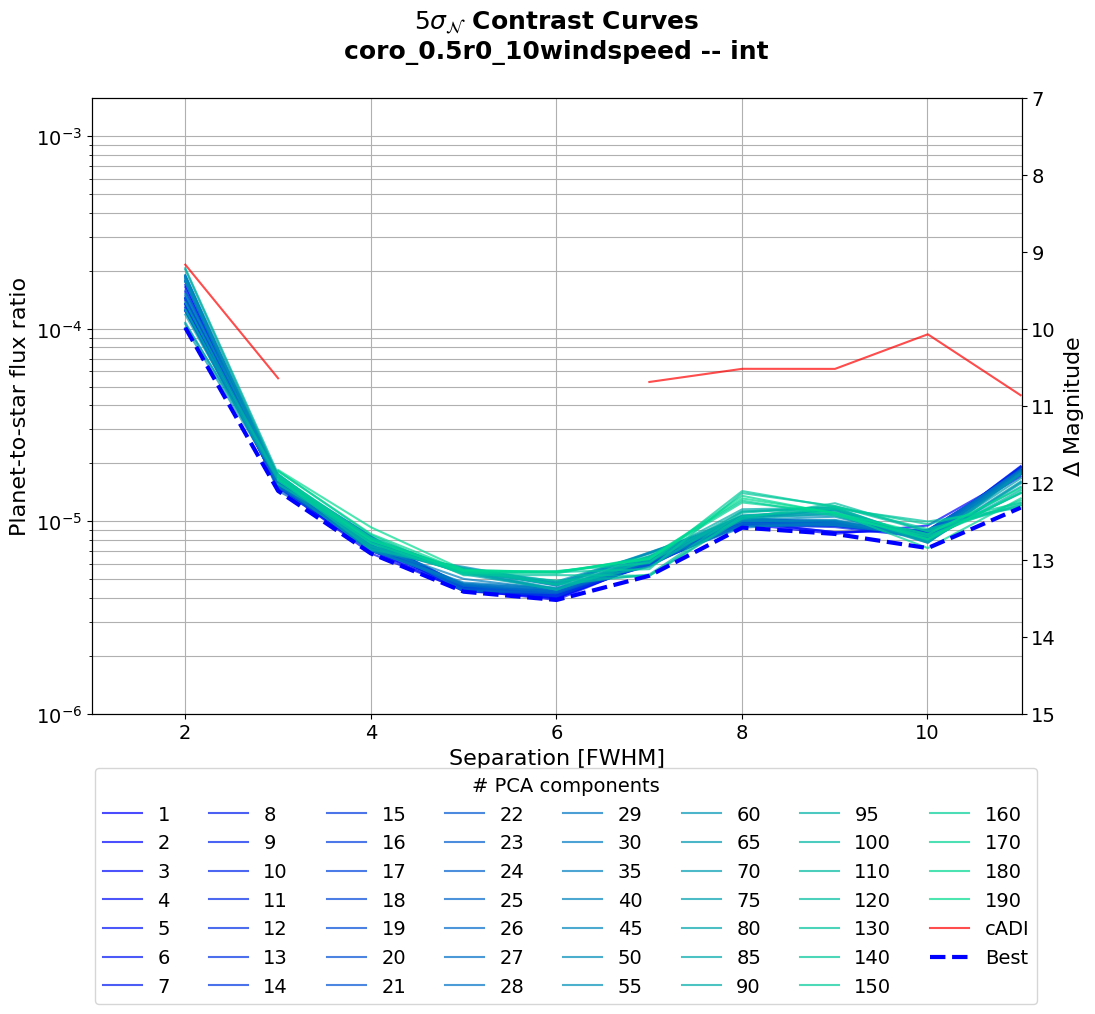

/tmp/ipykernel_653730/1206129900.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap(cmap)   # seaborn-style colormap available in mpl
/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tables/path.py:146: NaturalNameWarning: object name is not a valid Python identifier: 'coro_0.5r0_10windspeed_pred'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


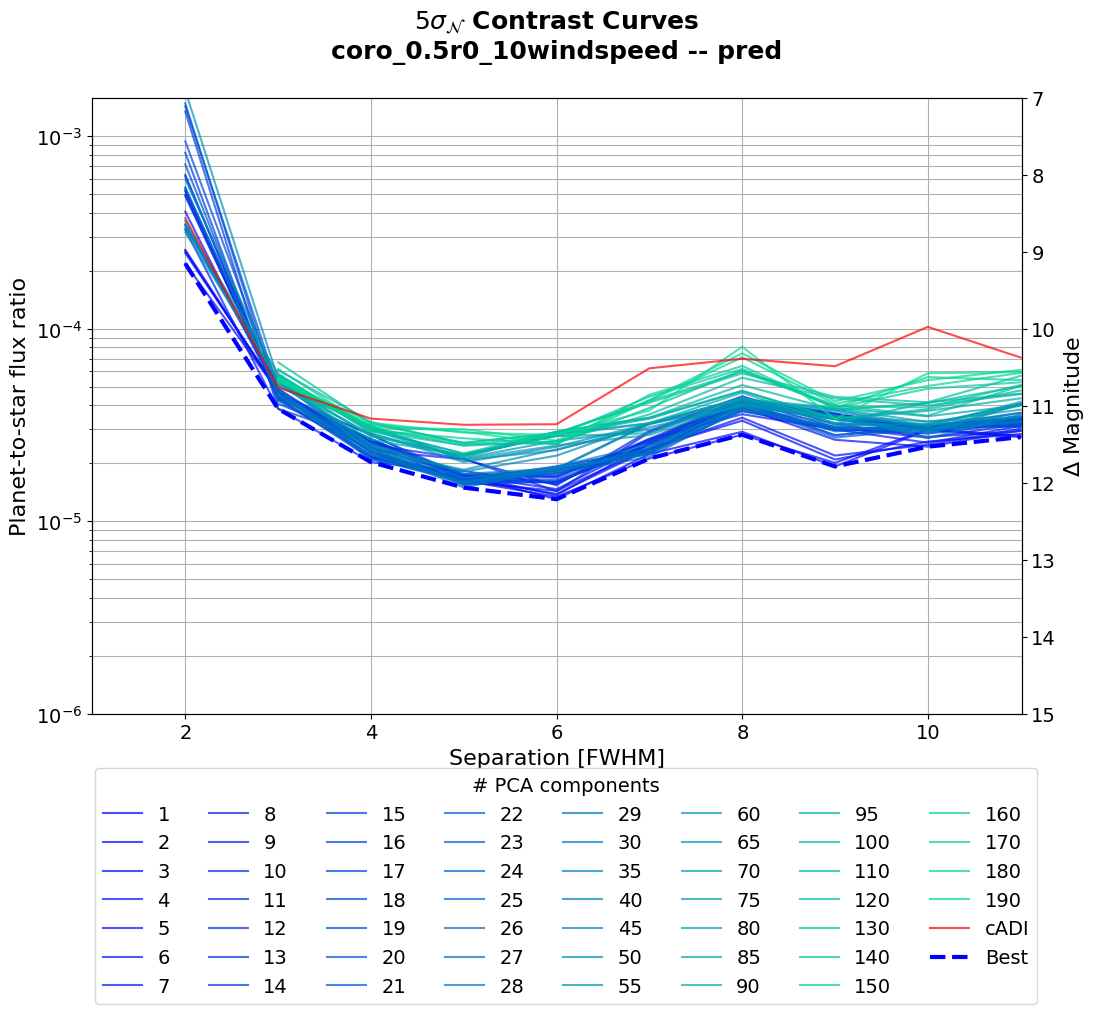

In [87]:
rangey = (15,7)
curves_output_path = '/home/aosimul/noah/results/animations'
for dataset_name, dataset in datasets.items():
    result = plot_contrast_curves(grids[dataset_name][0], rangey, curves_output_path, name+'_'+dataset_name, cmap = 'winter', title =(r"$5 \sigma_{\mathcal{N}}$ Contrast Curves" +f"\n{name} -- {dataset_name}"))
    result.to_hdf(
                        f"{curves_output_path}/overall_best.h5",
                        key=name+'_'+dataset_name,
                        mode="a"
                    )
    plt.show()

## Plot the overall best performance

In [3]:
#df = pd.read_hdf(f"{curves_output_path}/overall_best.h5", key = '')
curves_output_path = '/home/aosimul/noah/results/animations'

with pd.HDFStore(f"{curves_output_path}/overall_best.h5") as store:
    print(store.keys())

df = pd.read_hdf(f"{curves_output_path}/overall_best.h5", key = 'coro_0.5r0_10windspeed_int')
df

['/coro_0.5r0_10windspeed_int', '/coro_0.5r0_10windspeed_pred']


,best_contrast,best_PCA
separation [FWHM],,
1.000413,inf,1
2.000826,0.000101,70
3.001239,0.000014,24
4.001651,0.000007,2
5.002064,0.000004,21
6.002477,0.000004,1
7.002890,0.000005,130
8.003303,0.000009,28
9.003716,0.000009,1


/tmp/ipykernel_837816/150742184.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('magma')   # seaborn-style colormap available in mpl


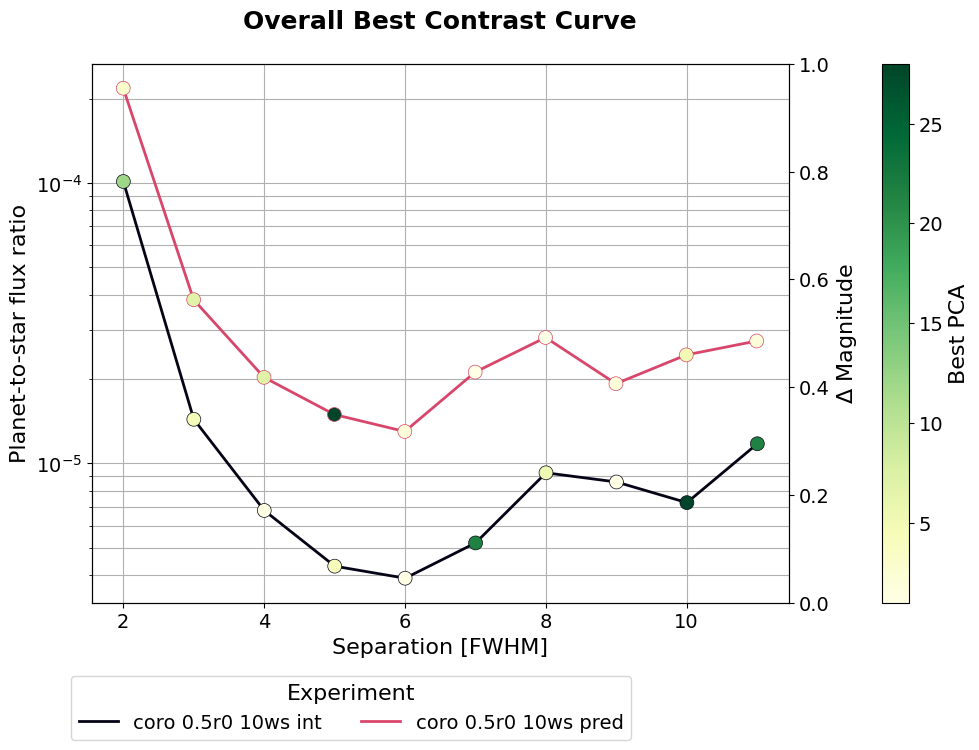

In [4]:
def plot_all_best(curves_output_path):
    with pd.HDFStore(f"{curves_output_path}/overall_best.h5") as store:
        fig, ax = plt.subplots(figsize=(12, 7))
        gs0 = fig.add_gridspec(1, 1)
        color_map = plt.cm.get_cmap('magma')   # seaborn-style colormap available in mpl
        colors = [color_map(int(i)) for i in np.round(np.linspace(10, 150, len(store.keys())))]



        for i, key in enumerate(store.keys()):
            df = store[key]

            ax.semilogy(
                df.index,
                df["best_contrast"],
                lw=2,
                color = colors[i],
                label=key.strip("/").replace('_', ' ').replace('windspeed', 'ws'),
            )

            sc = ax.scatter(
                df.index,
                df["best_contrast"],
                c=df["best_PCA"],
                cmap="YlGn",
                s=100,
                zorder=5,
                linewidth = 0.5,
                edgecolors= colors[i],
            )

        leg1 = fig.legend(
            fontsize=14,
            loc="lower left",
            bbox_to_anchor=(0.1, -(0.05 * len(store.keys()))),
            ncol=2,
            title="Experiment",
            title_fontsize=16, 
        )
        
    # Colorbar
    cbar = fig.colorbar(
        sc,
        ax=ax,               # or axis_contrast_curves
        pad=0.1,            # distance from the axes
    )

    cbar.set_label(
        "Best PCA",
        fontsize=16,
    )

    cbar.ax.tick_params(labelsize=14)
    ax.set_title(
            'Overall Best Contrast Curve',
            fontsize=18, fontweight="bold", y=1.05)

    ax.set_xlabel("Separation [FWHM]", fontsize=16)
    ax.set_ylabel("Planet-to-star flux ratio", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(which='both')
    ax_mag = ax.twinx()
    ax_mag.set_ylabel(r"$\Delta$ Magnitude", fontsize=16)

    ax_mag.tick_params(axis="both", which="major", labelsize=14)

    plt.savefig(f"{(curves_output_path)}/Overall_Best_Contrast.png",
            bbox_inches="tight",
            bbox_extra_artists=(leg1,),
        )

plot_all_best(curves_output_path)